# HopeEXP — Task B: Detección de Emoción Desencadenante
**Modelo:** `microsoft/mdeberta-v3-base`  
**Tipo de tarea:** Clasificación multietiqueta (7 emociones)  
**Emociones:** sadness, joy, love, anger, fear, surprise, Nuetral/unclear

## 0. Setup e Imports

In [1]:
%pip install transformers torch scikit-learn pandas numpy matplotlib seaborn sentencepiece protobuf

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# Añadir el directorio raíz al path para importar src/
sys.path.insert(0, os.path.abspath(".."))

from src.data_utils import (
    load_split,
    apply_cleaning,
    add_emotion_vectors,
    compute_class_weights,
    emotion_distribution,
    cooccurrence_matrix,
    format_predictions_for_submission,
    save_submission,
    EMOTION_LABELS,
)
from src.dataset import build_all_dataloaders
from src.model import build_model, build_tokenizer, load_model, count_parameters, CANDIDATE_MODELS, list_candidate_models
from src.metrics import (
    compute_metrics,
    print_metrics,
    find_best_threshold,
    find_best_threshold_per_class,
    classification_report_str,
)
from src.trainer import train, evaluate_epoch, predict, compare_models

print("Imports correctos")

Imports correctos


In [3]:
# ── Reproducibilidad ──────────────────────────────────────────
SEED = 42

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# ── Dispositivo ───────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Dispositivo: cuda
GPU: NVIDIA A100-SXM4-80GB


## 1. Configuración de Hiperparámetros

In [4]:
# ── Rutas de datos ────────────────────────────────────────────
# Solo hay train y test
TRAIN_PATH = "./HopeEXP_Train.jsonl"
TEST_PATH  = "./HopeEXP_Test_unlabeled.jsonl"
DEV_SIZE   = 0.20   # fracción del train que se usará como dev

# ── Columnas del dataset ──────────────────────────────────────
# load_split() genera automáticamente estas columnas normalizadas:
TEXT_COL    = "text"
EMOTION_COL = "trigger_emotions"
ID_COL      = "id"
LANG_COL    = "lang"    # "EN" o "ES"

# ── Modelo ────────────────────────────────────────────────────
MODEL_NAME  = "microsoft/mdeberta-v3-base"
NUM_LABELS  = len(EMOTION_LABELS)   # 7
MAX_LENGTH  = 512                   # ajustar según el EDA de longitudes
DROPOUT     = 0.1

# ── Entrenamiento ─────────────────────────────────────────────
BATCH_SIZE  = 16
COMPARISON_EPOCHS = 3            # épocas rápidas para comparar arquitecturas
NUM_EPOCHS  = 25
LR          = 2e-5
WARMUP_RATIO = 0.1
WEIGHT_DECAY = 0.01
PATIENCE    = 3           # épocas sin mejora para early stopping

# ── Evaluación ────────────────────────────────────────────────
THRESHOLD   = 0.5         # se optimizará en la sección de búsqueda
USE_POS_WEIGHT = True     # ponderar clases desbalanceadas

# ── Salidas ───────────────────────────────────────────────────
OUTPUT_DIR     = "./outputs"
BEST_MODEL_NAME = "best_model_task_b.pt"

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Configuración lista")

Configuración lista


## 2. Carga y Preprocesamiento de Datos

In [5]:
from sklearn.model_selection import train_test_split as sk_split

# Cargar train completo y test (sin etiquetas)
full_train_df = load_split(TRAIN_PATH)
test_df       = load_split(TEST_PATH)

# Partir train en train/dev estratificando por primary_label
# para que ambos splits tengan la misma distribución de clases
train_df, dev_df = sk_split(
    full_train_df,
    test_size=DEV_SIZE,
    random_state=SEED,
    stratify=full_train_df["primary_label"],
)
train_df = train_df.reset_index(drop=True)
dev_df   = dev_df.reset_index(drop=True)

print(f"Train completo: {len(full_train_df)} muestras")
print(f"  → Train: {len(train_df)} | Dev: {len(dev_df)}  (split {int((1-DEV_SIZE)*100)}/{int(DEV_SIZE*100)})")
print(f"  → Test (sin etiquetas): {len(test_df)} muestras")
print()
print("Distribución primary_label en train vs dev:")
dist_check = full_train_df.groupby("primary_label").size().rename("total")
dist_tr = train_df.groupby("primary_label").size().rename("train")
dist_dv = dev_df.groupby("primary_label").size().rename("dev")
import pandas as pd
print(pd.concat([dist_check, dist_tr, dist_dv], axis=1))

train_df.head(3)

Train completo: 4857 muestras
  → Train: 3885 | Dev: 972  (split 80/20)
  → Test (sin etiquetas): 2082 muestras

Distribución primary_label en train vs dev:
                  total  train  dev
primary_label                      
General Hope        937    749  188
Hopelessness        419    335   84
Not Hope           1400   1120  280
Realistic Hope      701    561  140
Sarcastic Hope      700    560  140
Unrealistic Hope    700    560  140


,row_id,lang,title,selftext,primary_label,span_annotations,trigger_emotions,text,id
0,5377,EN,My Partner Finally Remembered My Birthday—How ...,"After three years together, my significant oth...",Sarcastic Hope,[{'span': 'I have so much hope that things wil...,"[surprise, sadness, anger]",My Partner Finally Remembered My Birthday—How ...,5377
1,7161,EN,Reddittors make finding answers ridiculously t...,"Every reddit post that poses a question, the t...",Not Hope,[],[anger],Reddittors make finding answers ridiculously t...,7161
2,4124,ES,Alguien está o ha estado en una banda?,Me gustaría estar en una banda musical pero no...,Realistic Hope,[{'span': 'Me gustaría estar en una banda musi...,[Nuetral/unclear],Alguien está o ha estado en una banda?. Me gus...,4124


In [6]:
# ── Limpieza de texto ─────────────────────────────────────────
# Ajusta los flags según los hallazgos del EDA
CLEAN_KWARGS = dict(
    remove_urls=True,
    remove_mentions=True,
    remove_hashtag_symbol=True,
    lowercase=False,   # DeBERTa es case-sensitive; mantener mayúsculas
)

train_df = apply_cleaning(train_df, text_col=TEXT_COL, **CLEAN_KWARGS)
dev_df   = apply_cleaning(dev_df,   text_col=TEXT_COL, **CLEAN_KWARGS)
# El test no tiene selftext etiquetado en algunos casos; se limpia igual
test_df = apply_cleaning(test_df, text_col=TEXT_COL, **CLEAN_KWARGS)

print("Ejemplo de texto limpio:")
print(train_df[TEXT_COL].iloc[0])

Ejemplo de texto limpio:
My Partner Finally Remembered My Birthday—How Refreshing. After three years together, my significant other actually showed up on time for once. Who knew it was possible? I mean, I only mentioned it casually forty-seven times in the past month. The flowers he grabbed from the gas station two minutes before arriving really set the romantic tone. And when he said 'happy birthday' while scrolling through his phone, I thought, 'wow, this is definitely the moment I'll cherish forever.' I'm sure next year will be even more special—maybe he'll remember without me having to create a calendar reminder for him. The bar is truly on the floor, but somehow he keeps finding new ways to limbo under it. I have so much hope that things will magically change without him actually putting in any effort whatsoever.


In [7]:
# ── Codificación de etiquetas a vectores binarios ─────────────
train_df = add_emotion_vectors(train_df, emotions_col=EMOTION_COL)
dev_df   = add_emotion_vectors(dev_df,   emotions_col=EMOTION_COL)

# Extraer listas para el Dataset
train_texts  = train_df[TEXT_COL].tolist()
train_labels = train_df["emotion_vector"].tolist()

dev_texts    = dev_df[TEXT_COL].tolist()
dev_labels   = dev_df["emotion_vector"].tolist()

# Test no tiene etiquetas — solo textos e ids
test_texts = test_df[TEXT_COL].tolist()
test_ids   = test_df[ID_COL].tolist()

print("Vector de ejemplo:", train_labels[0])
print("Emociones:         ", [EMOTION_LABELS[i] for i, v in enumerate(train_labels[0]) if v == 1])

Vector de ejemplo: [1, 0, 0, 1, 0, 1, 0]
Emociones:          ['sadness', 'anger', 'surprise']


## 3. Análisis de Desbalanceo de Clases

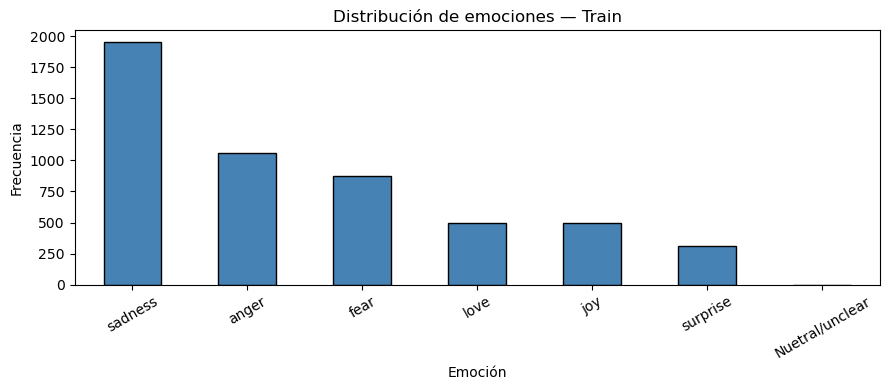

sadness            1949
anger              1061
fear                875
love                498
joy                 494
surprise            311
Nuetral/unclear       0
dtype: int64


In [8]:
# Distribución de emociones en train
dist = emotion_distribution(train_df, emotions_col=EMOTION_COL)

fig, ax = plt.subplots(figsize=(9, 4))
dist.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Distribución de emociones — Train")
ax.set_xlabel("Emoción")
ax.set_ylabel("Frecuencia")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "emotion_distribution.png"), dpi=150)
plt.show()
print(dist)

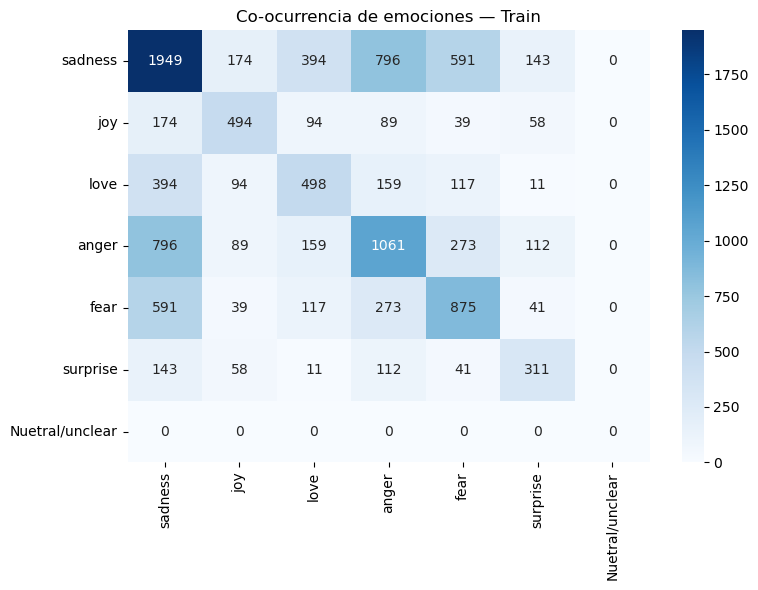

In [9]:
# Matriz de co-ocurrencia
cooc = cooccurrence_matrix(train_df, emotions_col=EMOTION_COL)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cooc, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Co-ocurrencia de emociones — Train")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "emotion_cooccurrence.png"), dpi=150)
plt.show()

In [10]:
# ── Pesos positivos para BCEWithLogitsLoss ────────────────────
pos_weights_np = compute_class_weights(train_df, emotions_col=EMOTION_COL)
pos_weight = torch.tensor(pos_weights_np) if USE_POS_WEIGHT else None

print("Pesos positivos por clase:")
for label, w in zip(EMOTION_LABELS, pos_weights_np):
    print(f"  {label:12s}: {w:.2f}")

Pesos positivos por clase:
  sadness     : 0.99
  joy         : 6.86
  love        : 6.80
  anger       : 2.66
  fear        : 3.44
  surprise    : 11.49
  Nuetral/unclear: 2.74


## 4. Tokenizador y DataLoaders

In [11]:
tokenizer = build_tokenizer(MODEL_NAME)
print(f"Tokenizer cargado: {MODEL_NAME}")

# Verificar longitudes reales de los textos
sample_lengths = [
    len(tokenizer.encode(t, add_special_tokens=True))
    for t in train_texts[:500]
]
print(f"Longitud media tokens (muestra 500): {np.mean(sample_lengths):.1f}")
print(f"Percentil 95: {np.percentile(sample_lengths, 95):.0f}")
print(f"Máximo: {max(sample_lengths)}")
print(f"MAX_LENGTH configurado: {MAX_LENGTH}")

Tokenizer cargado: microsoft/mdeberta-v3-base
Longitud media tokens (muestra 500): 332.8
Percentil 95: 770
Máximo: 5954
MAX_LENGTH configurado: 512


In [12]:
loaders = build_all_dataloaders(
    train_texts=train_texts,
    train_labels=train_labels,
    dev_texts=dev_texts,
    dev_labels=dev_labels,
    tokenizer=tokenizer,
    test_texts=test_texts,
    max_length=MAX_LENGTH,
    batch_size=BATCH_SIZE,
    num_workers=0,
)

print(f"Batches — Train: {len(loaders['train'])} | Dev: {len(loaders['dev'])}", end="")
if "test" in loaders:
    print(f" | Test: {len(loaders['test'])}")
else:
    print()

# Verificar un batch
sample_batch = next(iter(loaders["train"]))
print("\nForma de un batch:")
for k, v in sample_batch.items():
    print(f"  {k}: {v.shape}")

Batches — Train: 243 | Dev: 61 | Test: 131

Forma de un batch:
  input_ids: torch.Size([16, 512])
  attention_mask: torch.Size([16, 512])
  token_type_ids: torch.Size([16, 512])
  labels: torch.Size([16, 7])


## 5. Comparación de Modelos

Antes de entrenar al máximo, comparamos varias arquitecturas con pocas épocas
(`COMPARISON_EPOCHS`) para identificar la más prometedora.
Solo el ganador se entrena después con todas las épocas (`NUM_EPOCHS`).
Esto es más eficiente que hacer HPO sobre un único modelo.


In [13]:
# Listar candidatos multilingüe disponibles
list_candidate_models(multilingual_only=True)

# Seleccionar modelos multilingüe para la comparación rápida
candidate_names = [m["name"] for m in CANDIDATE_MODELS if m["multilingual"]]

# Comparar arquitecturas con COMPARISON_EPOCHS épocas cada una.
# Si no quieres comparar, comenta la llamada y asigna manualmente:
#   BEST_ARCH = MODEL_NAME
comparison_results = compare_models(
    model_names=candidate_names,
    train_loader=loaders["train"],
    dev_loader=loaders["dev"],
    device=DEVICE,
    num_labels=NUM_LABELS,
    num_epochs=COMPARISON_EPOCHS,
    learning_rate=LR,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    threshold=THRESHOLD,
    pos_weight=pos_weight,
    save_dir=os.path.join(OUTPUT_DIR, "model_comparison"),
    monitor_metric="f1_macro",
    early_stopping_patience=2,
)

# Arquitectura ganadora
BEST_ARCH = comparison_results.iloc[0]["model"]
print(f"\nMejor arquitectura: {BEST_ARCH}")
print(f"   F1 Macro (exploración {COMPARISON_EPOCHS} épocas): "
      f"{comparison_results.iloc[0]['f1_macro']:.4f}")


Modelo                                        Multilingüe    Descripción
----------------------------------------------------------------------------------------------------
microsoft/mdeberta-v3-base                    ✓              mDeBERTa v3 – fuerte en tareas multilingüe, mejor baseline general
xlm-roberta-base                              ✓              XLM-RoBERTa base – robusto, ampliamente usado en NLP multilingüe
xlm-roberta-large                             ✓              XLM-RoBERTa large – mayor capacidad, requiere más VRAM
bert-base-multilingual-cased                  ✓              mBERT cased – baseline clásico multilingüe

  Evaluando: microsoft/mdeberta-v3-base


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/mdeberta-v3-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
mask_predictions.LayerNorm.bias            | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight    | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight          | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias      | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight        | UNEXPECTED |  | 
mask_predictions.dense.weight              | UNEXPECTED |  | 
mask_predictions.classifier.weight         | UNEXPECTED |  | 
deberta.embeddings.word_embeddings._weight | UNEXPECTED |  | 
mask_predictions.classifier.bias           | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias          | UNEXPECTED |  | 
mask_predictions.dense.bias                | UNEXPECTED |  | 
lm_predictions.lm_head.bias                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/ar

Iniciando entrenamiento: 3 épocas, lr=2e-05
- Total steps: 729 | Warmup steps: 72
- Early stopping: patience=2, monitor='f1_macro'

Época 1/3  [127.8s]
- Train Loss: 1.0761  |  Dev Loss: 0.9112
- Dev f1_macro: 0.4728
Modelo guardado en ./outputs/model_comparison/microsoft_mdeberta-v3-base_best.pt
Nuevo mejor modelo guardado (f1_macro=0.4728)

Época 2/3  [127.1s]
- Train Loss: 0.7578  |  Dev Loss: 0.6610
- Dev f1_macro: 0.5918
Modelo guardado en ./outputs/model_comparison/microsoft_mdeberta-v3-base_best.pt
Nuevo mejor modelo guardado (f1_macro=0.5918)

Época 3/3  [127.0s]
- Train Loss: 0.6140  |  Dev Loss: 0.6394
- Dev f1_macro: 0.6144
Modelo guardado en ./outputs/model_comparison/microsoft_mdeberta-v3-base_best.pt
Nuevo mejor modelo guardado (f1_macro=0.6144)

- Entrenamiento finalizado. Mejor f1_macro: 0.6144

  Evaluando: xlm-roberta-base


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Iniciando entrenamiento: 3 épocas, lr=2e-05
- Total steps: 729 | Warmup steps: 72
- Early stopping: patience=2, monitor='f1_macro'

Época 1/3  [260.1s]
- Train Loss: 0.9012  |  Dev Loss: 0.5758
- Dev f1_macro: 0.6556
Modelo guardado en ./outputs/model_comparison/xlm-roberta-large_best.pt
Nuevo mejor modelo guardado (f1_macro=0.6556)

Época 2/3  [260.8s]
- Train Loss: 0.5416  |  Dev Loss: 0.4966
- Dev f1_macro: 0.7245
Modelo guardado en ./outputs/model_comparison/xlm-roberta-large_best.pt
Nuevo mejor modelo guardado (f1_macro=0.7245)

Época 3/3  [260.4s]
- Train Loss: 0.3697  |  Dev Loss: 0.5098
- Dev f1_macro: 0.7418
Modelo guardado en ./outputs/model_comparison/xlm-roberta-large_best.pt
Nuevo mejor modelo guardado (f1_macro=0.7418)

- Entrenamiento finalizado. Mejor f1_macro: 0.7418

  Evaluando: bert-base-multilingual-cased


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Iniciando entrenamiento: 3 épocas, lr=2e-05
- Total steps: 729 | Warmup steps: 72
- Early stopping: patience=2, monitor='f1_macro'

Época 1/3  [83.5s]
- Train Loss: 0.9169  |  Dev Loss: 0.7078
- Dev f1_macro: 0.5797
Modelo guardado en ./outputs/model_comparison/bert-base-multilingual-cased_best.pt
Nuevo mejor modelo guardado (f1_macro=0.5797)

Época 2/3  [83.3s]
- Train Loss: 0.6104  |  Dev Loss: 0.6118
- Dev f1_macro: 0.6314
Modelo guardado en ./outputs/model_comparison/bert-base-multilingual-cased_best.pt
Nuevo mejor modelo guardado (f1_macro=0.6314)

Época 3/3  [83.1s]
- Train Loss: 0.4672  |  Dev Loss: 0.6257
- Dev f1_macro: 0.6699
Modelo guardado en ./outputs/model_comparison/bert-base-multilingual-cased_best.pt
Nuevo mejor modelo guardado (f1_macro=0.6699)

- Entrenamiento finalizado. Mejor f1_macro: 0.6699

  Ranking final de modelos
                       model  f1_macro  best_epoch  train_loss  dev_loss status
           xlm-roberta-large    0.7418           3      0.3697    0

## 6. Entrenamiento Completo del Mejor Modelo

Entrenamos `BEST_ARCH` con `NUM_EPOCHS` épocas completas y early stopping.


In [14]:
# Construir el modelo ganador desde cero
model = build_model(
    model_name=BEST_ARCH,
    num_labels=NUM_LABELS,
    dropout_prob=DROPOUT,
)
model = model.float()

n_params = count_parameters(model)
print(f"Arquitectura: {BEST_ARCH}")
print(f"Parámetros entrenables: {n_params:,}")
print(f"Cabeza clasificadora: {NUM_LABELS} etiquetas")


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Arquitectura: xlm-roberta-large
Parámetros entrenables: 559,897,607
Cabeza clasificadora: 7 etiquetas


In [15]:
# Reconstruir tokenizer y loaders con la arquitectura ganadora
tokenizer = build_tokenizer(BEST_ARCH)
loaders = build_all_dataloaders(
    train_texts=train_texts,
    train_labels=train_labels,
    dev_texts=dev_texts,
    dev_labels=dev_labels,
    tokenizer=tokenizer,
    test_texts=test_texts,
    max_length=MAX_LENGTH,
    batch_size=BATCH_SIZE,
    num_workers=0,
)
print(f"Loaders reconstruidos con tokenizer de: {BEST_ARCH}")

Loaders reconstruidos con tokenizer de: xlm-roberta-large


In [16]:
history = train(
    model=model,
    train_loader=loaders["train"],
    dev_loader=loaders["dev"],
    device=DEVICE,
    num_epochs=NUM_EPOCHS,          # entrenamiento completo
    learning_rate=LR,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    threshold=THRESHOLD,
    pos_weight=pos_weight,
    save_dir=OUTPUT_DIR,
    model_name=BEST_MODEL_NAME,
    early_stopping_patience=PATIENCE,
    monitor_metric="f1_macro",
    verbose=True,
)


Iniciando entrenamiento: 25 épocas, lr=2e-05
- Total steps: 6075 | Warmup steps: 607
- Early stopping: patience=3, monitor='f1_macro'

Época 1/25  [260.3s]
- Train Loss: 1.1059  |  Dev Loss: 0.8998
- Dev f1_macro: 0.4698
Modelo guardado en ./outputs/best_model_task_b.pt
Nuevo mejor modelo guardado (f1_macro=0.4698)

Época 2/25  [259.9s]
- Train Loss: 0.7534  |  Dev Loss: 0.5788
- Dev f1_macro: 0.6795
Modelo guardado en ./outputs/best_model_task_b.pt
Nuevo mejor modelo guardado (f1_macro=0.6795)

Época 3/25  [260.2s]
- Train Loss: 0.5999  |  Dev Loss: 0.6046
- Dev f1_macro: 0.6378
Sin mejora (1/3)

Época 4/25  [260.9s]
- Train Loss: 0.4519  |  Dev Loss: 0.5766
- Dev f1_macro: 0.7180
Modelo guardado en ./outputs/best_model_task_b.pt
Nuevo mejor modelo guardado (f1_macro=0.7180)

Época 5/25  [261.1s]
- Train Loss: 0.3415  |  Dev Loss: 0.6437
- Dev f1_macro: 0.7201
Modelo guardado en ./outputs/best_model_task_b.pt
Nuevo mejor modelo guardado (f1_macro=0.7201)

Época 6/25  [260.5s]
- Train 

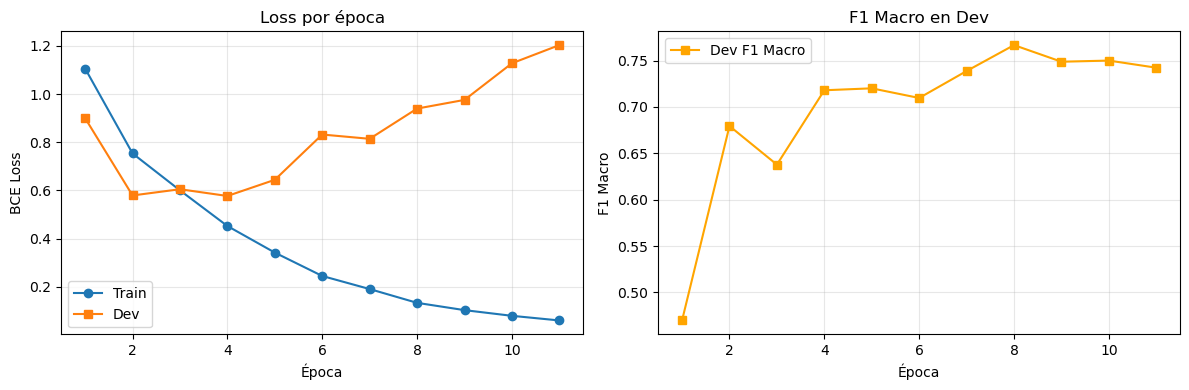

In [17]:
# ── Curvas de entrenamiento ───────────────────────────────────
epochs_run = range(1, len(history["train_loss"]) + 1)
dev_f1 = [m.get("f1_macro", 0) for m in history["dev_metrics"]]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(epochs_run, history["train_loss"], label="Train", marker="o")
axes[0].plot(epochs_run, history["dev_loss"],   label="Dev",   marker="s")
axes[0].set_title("Loss por época")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("BCE Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# F1 Macro
axes[1].plot(epochs_run, dev_f1, label="Dev F1 Macro", marker="s", color="orange")
axes[1].set_title("F1 Macro en Dev")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("F1 Macro")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150)
plt.show()

## 7. Evaluación del Mejor Modelo en Dev

In [18]:
# Cargar el mejor checkpoint guardado
best_model = load_model(
    path=os.path.join(OUTPUT_DIR, BEST_MODEL_NAME),
    model_name=BEST_ARCH,
    num_labels=NUM_LABELS,
    dropout_prob=DROPOUT,
    device=DEVICE,
)

best_model = best_model.float()

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-large
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo cargado desde ./outputs/best_model_task_b.pt


In [19]:
# Obtener probabilidades en dev
_, _, dev_probs, dev_true = evaluate_epoch(
    best_model, loaders["dev"], DEVICE, threshold=THRESHOLD
)

print(f"Formas — probs: {dev_probs.shape} | labels: {dev_true.shape}")

Formas — probs: (972, 7) | labels: (972, 7)


In [20]:
# ── Métricas con umbral por defecto (0.5) ─────────────────────
print("=== Evaluación con threshold=0.5 ===")
metrics_05 = compute_metrics(dev_true, dev_probs, threshold=0.5)
print_metrics(metrics_05)

print("\n" + classification_report_str(dev_true, dev_probs, threshold=0.5))

=== Evaluación con threshold=0.5 ===
  F1 Macro:    0.7667
  F1 Micro:    0.7826
  F1 Weighted: 0.7822
  Precision:   0.7456
  Recall:      0.7943
  Hamming Loss:0.1041
  Threshold:   0.50
--------------------------------------------------
  F1 por emoción:
    sadness     : 0.8270
    joy         : 0.6784
    love        : 0.6820
    anger       : 0.7722
    fear        : 0.7500
    surprise    : 0.8421
    Nuetral/unclear: 0.8154

                 precision    recall  f1-score   support

        sadness       0.77      0.89      0.83       489
            joy       0.72      0.64      0.68       120
           love       0.60      0.79      0.68       113
          anger       0.74      0.81      0.77       274
           fear       0.74      0.76      0.75       244
       surprise       0.86      0.82      0.84        78
Nuetral/unclear       0.79      0.85      0.82       237

      micro avg       0.75      0.82      0.78      1555
      macro avg       0.75      0.79      0.77  

## 8. Optimización del Umbral de Decisión

In [21]:
# ── Búsqueda de umbral global ─────────────────────────────────
print("=== Búsqueda de umbral global (maximiza F1 Macro) ===")
best_threshold, best_f1 = find_best_threshold(
    dev_true, dev_probs,
    metric="f1_macro",
    verbose=True,
)

=== Búsqueda de umbral global (maximiza F1 Macro) ===
   Threshold |     f1_macro
------------------------------
        0.10 |       0.7221
        0.15 |       0.7405
        0.20 |       0.7445
        0.25 |       0.7475
        0.30 |       0.7532
        0.35 |       0.7604
        0.40 |       0.7632
        0.45 |       0.7624
        0.50 |       0.7667
        0.55 |       0.7689
        0.60 |       0.7660
        0.65 |       0.7643
        0.70 |       0.7637
        0.75 |       0.7596
        0.80 |       0.7535
        0.85 |       0.7489
        0.90 |       0.7443

✅ Mejor umbral: 0.55  (f1_macro = 0.7689)


In [22]:
# ── Búsqueda de umbral por clase ──────────────────────────────
print("=== Búsqueda de umbral óptimo por clase ===")
best_thresholds_per_class = find_best_threshold_per_class(
    dev_true, dev_probs,
    label_names=EMOTION_LABELS,
)

=== Búsqueda de umbral óptimo por clase ===
Emoción         |   Umbral |       F1
--------------------------------------
sadness         |     0.55 |   0.8303
joy             |     0.40 |   0.6923
love            |     0.55 |   0.6848
anger           |     0.55 |   0.7754
fear            |     0.55 |   0.7572
surprise        |     0.60 |   0.8477
Nuetral/unclear |     0.70 |   0.8228


In [23]:
# ── Métricas con mejor umbral global ─────────────────────────
print(f"=== Evaluación con threshold={best_threshold:.2f} ===")
metrics_best = compute_metrics(dev_true, dev_probs, threshold=best_threshold)
print_metrics(metrics_best)

# Guardar el umbral óptimo para inferencia
OPTIMAL_THRESHOLD = best_threshold
print(f"\nUmbral óptimo guardado: {OPTIMAL_THRESHOLD:.2f}")

=== Evaluación con threshold=0.55 ===
  F1 Macro:    0.7689
  F1 Micro:    0.7854
  F1 Weighted: 0.7850
  Precision:   0.7561
  Recall:      0.7871
  Hamming Loss:0.1014
  Threshold:   0.55
--------------------------------------------------
  F1 por emoción:
    sadness     : 0.8303
    joy         : 0.6786
    love        : 0.6848
    anger       : 0.7754
    fear        : 0.7572
    surprise    : 0.8421
    Nuetral/unclear: 0.8140

Umbral óptimo guardado: 0.55


In [24]:
# ── Comparativa umbral por clase vs global ────────────────────
# Aplicar umbrales por clase manualmente
dev_pred_per_class = (dev_probs >= best_thresholds_per_class).astype(int)

from sklearn.metrics import f1_score
f1_per_class_thresh = f1_score(dev_true, dev_pred_per_class, average="macro", zero_division=0)
print(f"F1 Macro con umbrales por clase: {f1_per_class_thresh:.4f}")
print(f"F1 Macro con umbral global ({OPTIMAL_THRESHOLD:.2f}): {best_f1:.4f}")
print("→ Usar la estrategia con mayor F1 Macro")

F1 Macro con umbrales por clase: 0.7729
F1 Macro con umbral global (0.55): 0.7689
→ Usar la estrategia con mayor F1 Macro


## 9. Análisis de Errores

In [25]:
from src.metrics import binarize

dev_pred = binarize(dev_probs, OPTIMAL_THRESHOLD)

# Ejemplos mal clasificados
errors = []
for i in range(len(dev_texts)):
    true_emotions = [EMOTION_LABELS[j] for j, v in enumerate(dev_true[i]) if v == 1]
    pred_emotions = [EMOTION_LABELS[j] for j, v in enumerate(dev_pred[i]) if v == 1]
    if true_emotions != pred_emotions:
        errors.append({
            "text":  dev_texts[i],
            "true":  true_emotions,
            "pred":  pred_emotions,
        })

error_rate = len(errors) / len(dev_texts) * 100
print(f"Muestras con al menos 1 error: {len(errors)} ({error_rate:.1f}%)")
print()

# Mostrar primeros 5 errores
for e in errors[:5]:
    print(f"Texto: {e['text'][:100]}...")
    print(f"  Real: {e['true']}")
    print(f"  Pred: {e['pred']}")
    print()

Muestras con al menos 1 error: 433 (44.5%)

Texto: My Ex Will Definitely Come Back Once They See My Glow-Up. I'm absolutely thrilled about this breakup...
  Real: ['joy']
  Pred: ['sadness', 'love', 'anger']

Texto: Housing Dream Update: Found Perfect Home and Finally Fixed Everything. I'm so excited to share that ...
  Real: ['sadness', 'joy', 'love']
  Pred: ['love']

Texto: ¿Cómo puedo conseguir que mi jefe me ame tanto que me ascienda sin hacer nada?. Llevo tres meses en ...
  Real: ['sadness', 'love']
  Pred: ['joy', 'love']

Texto: Claro, seguro que esta vez será diferente. Ahí estoy yo, otra vez esperando que mi pareja finalmente...
  Real: ['fear']
  Pred: ['sadness', 'anger', 'fear']

Texto: No sé qué estudiar. Todo lo que me gusta da dinero. Estoy estudiando hace 4 año estudiando una carre...
  Real: ['sadness']
  Pred: ['sadness', 'love']



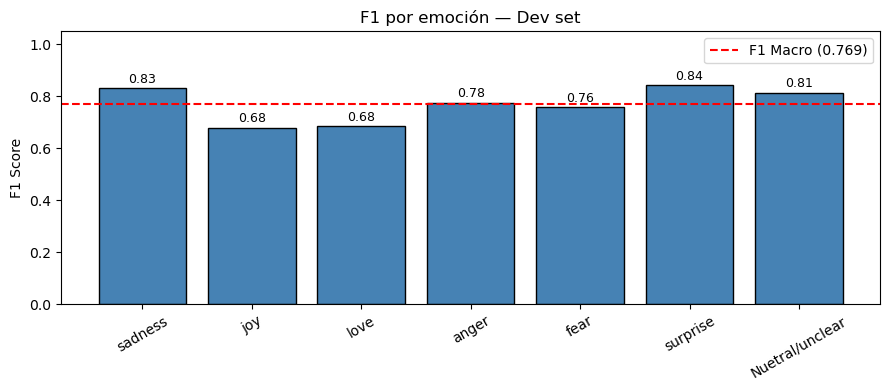

In [26]:
# F1 por clase — visualización
f1_per_class = [metrics_best.get(f"f1_{l}", 0) for l in EMOTION_LABELS]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(EMOTION_LABELS, f1_per_class, color="steelblue", edgecolor="black")
ax.axhline(metrics_best["f1_macro"], color="red", linestyle="--", label=f"F1 Macro ({metrics_best['f1_macro']:.3f})")
ax.set_title("F1 por emoción — Dev set")
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1.05)
ax.legend()
ax.tick_params(axis="x", rotation=30)
for bar, val in zip(bars, f1_per_class):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.2f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "f1_per_class.png"), dpi=150)
plt.show()

## 10. Generación de Predicciones para Test (Submission)

In [27]:
print("Generando predicciones para test...")
test_probs = predict(best_model, loaders["test"], DEVICE)
print(f"Probabilidades test: {test_probs.shape}")

Generando predicciones para test...
Probabilidades test: (2082, 7)


In [28]:
# Usar el umbral óptimo encontrado en dev
submission_df = format_predictions_for_submission(
        ids=test_ids,
        predictions=test_probs,
        label_set=EMOTION_LABELS,
        threshold=OPTIMAL_THRESHOLD,
    )

print(f"Submission — primeras filas:")
print(submission_df.head())
print(f"\nDistribución de predicciones en test:")
all_preds = [e for emotions in submission_df["trigger_emotions"] for e in emotions]
from collections import Counter
print(Counter(all_preds))

Submission — primeras filas:
     id            trigger_emotions
0    17            [sadness, anger]
1  3512           [Nuetral/unclear]
2  4863           [Nuetral/unclear]
3  6917             [sadness, fear]
4  8586  [sadness, anger, surprise]

Distribución de predicciones en test:
Counter({'sadness': 1171, 'anger': 636, 'Nuetral/unclear': 540, 'fear': 496, 'love': 332, 'joy': 225, 'surprise': 181})


In [29]:
submission_path = os.path.join(OUTPUT_DIR, "submission_task_b.json")
save_submission(submission_df, submission_path)
print(f"Submission lista para subir a CodaBench: {submission_path}")

Submission guardada en ./outputs/submission_task_b.json
Submission lista para subir a CodaBench: ./outputs/submission_task_b.json


## 11. Guardado del Experimento

In [30]:
experiment_config = {
    "model_name":        BEST_ARCH,
    "max_length":        MAX_LENGTH,
    "batch_size":        BATCH_SIZE,
    "learning_rate":     LR,
    "warmup_ratio":      WARMUP_RATIO,
    "weight_decay":      WEIGHT_DECAY,
    "dropout":           DROPOUT,
    "use_pos_weight":    USE_POS_WEIGHT,
    "seed":              SEED,
    "optimal_threshold": float(OPTIMAL_THRESHOLD),
    "best_dev_f1_macro": float(best_f1),
    "dev_metrics":       {k: float(v) for k, v in metrics_best.items()},
}

config_path = os.path.join(OUTPUT_DIR, "experiment_config.json")
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(experiment_config, f, indent=2, ensure_ascii=False)

print("Configuración del experimento guardada:")
print(json.dumps(experiment_config, indent=2))

Configuración del experimento guardada:
{
  "model_name": "xlm-roberta-large",
  "max_length": 512,
  "batch_size": 16,
  "learning_rate": 2e-05,
  "warmup_ratio": 0.1,
  "weight_decay": 0.01,
  "dropout": 0.1,
  "use_pos_weight": true,
  "seed": 42,
  "optimal_threshold": 0.5500000000000002,
  "best_dev_f1_macro": 0.7689269490529494,
  "dev_metrics": {
    "f1_macro": 0.7689269490529494,
    "f1_micro": 0.7854477611940298,
    "f1_weighted": 0.7849970839085567,
    "precision_macro": 0.7561223863907263,
    "recall_macro": 0.7871398744005154,
    "hamming_loss": 0.10141093474426807,
    "threshold": 0.5500000000000002,
    "f1_sadness": 0.8302972195589645,
    "f1_joy": 0.6785714285714286,
    "f1_love": 0.6848249027237354,
    "f1_anger": 0.775438596491228,
    "f1_fear": 0.757201646090535,
    "f1_surprise": 0.8421052631578947,
    "f1_Nuetral/unclear": 0.8140495867768595
  }
}
